In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load cleaned dataset
df = pd.read_csv("../data/cleaned_credit_applications.csv")

df.shape

(500, 29)

In [2]:
df.head()

,_id,full_name,email,ssn,ip_address,gender,gender_raw,date_of_birth,date_of_birth_raw,age,...,loan_approved,interest_rate,approved_amount,rejection_reason,total_spending,alcohol_spend,email_missing,ssn_missing,dob_missing,ssn_conflict
0,app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,Male,2001-03-09,2001-03-09,24.0,...,False,NaN,NaN,algorithm_risk_score,1517,247,False,False,False,False
1,app_037,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,M,1992-03-31,1992-03-31,33.0,...,False,NaN,NaN,algorithm_risk_score,947,0,False,False,False,False
2,app_215,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,Male,1989-10-24,1989-10-24,36.0,...,True,3.7,59000.0,NaN,109,0,False,False,False,False
3,app_024,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,Male,1983-04-25,1983-04-25,42.0,...,True,4.3,34000.0,NaN,575,0,False,False,False,False
4,app_184,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,M,1999-05-21,1999-05-21,26.0,...,False,NaN,NaN,algorithm_risk_score,463,0,False,False,False,False


In [3]:
df.columns

Index(['_id', 'full_name', 'email', 'ssn', 'ip_address', 'gender',
       'gender_raw', 'date_of_birth', 'date_of_birth_raw', 'age', 'zip_code',
       'annual_income', 'annual_income_raw', 'income_imputed',
       'credit_history_months', 'credit_history_months_flag', 'debt_to_income',
       'dti_flag', 'savings_balance', 'loan_approved', 'interest_rate',
       'approved_amount', 'rejection_reason', 'total_spending',
       'alcohol_spend', 'email_missing', 'ssn_missing', 'dob_missing',
       'ssn_conflict'],
      dtype='object')

### Target: Loan approved

In [4]:
df["loan_approved"].value_counts()

loan_approved
True     292
False    208
Name: count, dtype: int64

In [5]:
df["loan_approved"].mean()

np.float64(0.584)

### Approval rate by gender

In [6]:
df["gender"].value_counts()

gender
Female    251
Male      247
Name: count, dtype: int64

In [7]:
approval_by_gender = (
    df.groupby("gender")["loan_approved"]
      .agg(["count", "mean"])
      .rename(columns={"count": "n_applications", "mean": "approval_rate"})
)

approval_by_gender

,n_applications,approval_rate
gender,,
Female,251,0.505976
Male,247,0.659919


In [9]:
rate_male = approval_by_gender.loc["Male", "approval_rate"]
rate_female = approval_by_gender.loc["Female", "approval_rate"]

DI = rate_female / rate_male
DI

np.float64(0.7667245129909809)

In [11]:
gap = rate_male - rate_female
gap

np.float64(0.1539429327225511)

### age X gender

In [12]:
df["age"].describe()

count    496.000000
mean      40.750000
std       10.965971
min       23.000000
25%       32.000000
50%       39.000000
75%       47.000000
max       67.000000
Name: age, dtype: float64

In [13]:
df["age_bin"] = pd.cut(
    df["age"],
    bins=[18, 29, 39, 49, 59, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"]
)

df["age_bin"].value_counts()

age_bin
30-39    171
40-49    138
18-29     82
50-59     62
60+       43
Name: count, dtype: int64

In [14]:
approval_by_age = (
    df.groupby("age_bin")["loan_approved"]
      .agg(["count", "mean"])
      .rename(columns={"count": "n_applications", "mean": "approval_rate"})
)

approval_by_age

/var/folders/_3/k141xpjj0nq33fn7_4yjz1v80000gn/T/ipykernel_8339/1768708344.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_bin")["loan_approved"]


,n_applications,approval_rate
age_bin,,
18-29,82,0.414634
30-39,171,0.567251
40-49,138,0.688406
50-59,62,0.564516
60+,43,0.651163


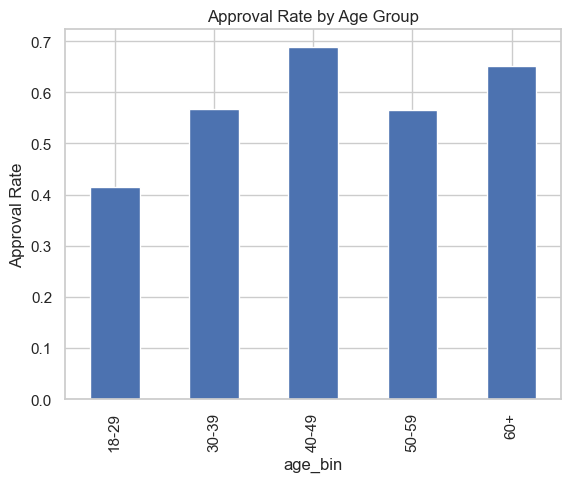

In [15]:
approval_by_age["approval_rate"].plot(kind="bar")
plt.title("Approval Rate by Age Group")
plt.ylabel("Approval Rate")
plt.show()

In [16]:
approval_gender_age = (
    df.groupby(["age_bin", "gender"])["loan_approved"]
      .mean()
      .unstack()
)

approval_gender_age

/var/folders/_3/k141xpjj0nq33fn7_4yjz1v80000gn/T/ipykernel_8339/922906468.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["age_bin", "gender"])["loan_approved"]


gender,Female,Male
age_bin,,
18-29,0.340909,0.500000
30-39,0.488095,0.643678
40-49,0.617647,0.757143
50-59,0.466667,0.645161
60+,0.608696,0.700000


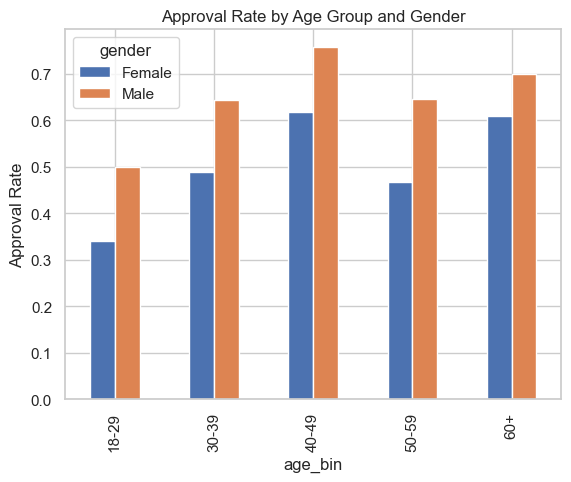

In [17]:
approval_gender_age.plot(kind="bar")
plt.title("Approval Rate by Age Group and Gender")
plt.ylabel("Approval Rate")
plt.show()

In [18]:
DI_by_age = approval_gender_age["Female"] / approval_gender_age["Male"]
DI_by_age

age_bin
18-29    0.681818
30-39    0.758291
40-49    0.815760
50-59    0.723333
60+      0.869565
dtype: float64

The magnitude of disparate impact varies substantially across age groups.
Female applicants aged 18–29 and 50–59 experience the strongest relative disadvantage (DI = 0.68 and 0.72 respectively), while the gap narrows significantly among applicants aged 60+ (DI = 0.87).
This indicates a significant gender × age interaction effect.